# Database Query Speedup: Grover's Algorithm with Qiskit

***Bandung Quantum Day 2026***

*Prepared by: Yozef Tjandra (for any enquiries, please reach me out at: yozef.g.tjandra@gmail.com)*

Objectives: By the end of this session, you would be able to
* Understand the operational mechanism of a quantum oracle under the context of searching problem.
* Using Qiskit, implement the Grover's algorithm to demonstrate the quantum oracle search speedup, in comparison to classical approaches.

This notebook takes you from the classical search problem, through how a quantum computer can query an oracle, to building and running Grover's algorithm yourself — and finally guessing the contents of two **secret** oracles using nothing but what you observe.

**Sections:**
1. Intro to the oracle search problem
2. Classical oracle
3. Quantum oracle
4. Anatomy of Grover's algorithm
5. Build Grover layer-by-layer - Demonstration of Quantum Speedup
6. Main Activity: Guess the secret oracles
7. *(Optional, self-paced)* Build your own oracle from scratch

## Setup

Run the cell below once at the start of the session. It installs the necessary libraries and the `grover_workshop` support package used throughout this notebook.

In [ ]:
!pip install qiskit pylatexenc
!pip install git+https://github.com/yozeftjandra/grover-workshop.git -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Built-in modules
import math
import random
import matplotlib.pyplot as plt

# Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.primitives import StatevectorSampler

# Workshop support package
from grover_workshop import (
    build_quantum_oracle,
    EXAMPLE_MARKED_STATES,
    quantum_query,
    angle_to_marked,
    get_secret_oracle_1,
    get_secret_oracle_2,
    grade_5_1_superposition,
    grade_5_2_single_layer,
    grade_5_3_readout,
    grade_5_4_iteration_count,
    grade_5_5_full_run,
    grade_6_1_query_intro,
    grade_6_2_secret_oracle,
    grade_6_3_bonus_discovery,
    grade_7_3_step_a,
    grade_7_3_step_a_exercise,
    grade_7_4_step_b,
    grade_7_5_step_c,
)

## 1 - Introduction to the oracle search problem

Imagine you're handed a black box. You can feed it any guess you like, and it answers only yes or no: *"is this the one?"* You can't look inside — you don't know how it decides, only that it decides correctly.

This is the **oracle search problem**: find whatever the box says yes to, using as few questions as possible.

![Oracle Illustration](https://i.ibb.co.com/gb3L0VQY/Gemini-Generated-Image-qsx555qsx555qsx5.jpg)

Despite it might look merely playful, the oracle setup is relatively ubiquitous in many computational problems such as database query and combinatorial optimisation. To make it a little bit more precise, we can model the oracle as a binary-valued function as follows:

$$
f:\{0,1\}^n\rightarrow \{0,1\}
$$

where the function formula is hidden. However, for any binary string we feed as the input of the function, we will always be able to retrieve the output. Here is a quick breakdown of the oracle setup for each problem.

| Computational <br>Problem | Description | What is the input <br>$\mathbf{x}\in \{0,1\}^n$? | What is the output <br>$f(\mathbf{x})\in \{0,1\}$? | What is the oracle function <br>formula $f$? |
|---|---|---|---|---|
| Unstructured <br>Search | Given an array whose indices take $n$ bits of register and a value $k$. <br>Find all the indices at which the array takes values $k$ | An index register in <br>binary form | Whether the array at index <br>$\mathbf{x}$ has value $k$ | Array value checking |
| Combinatorial <br>Optimisation | Given an objective function $f$ with $n$ binary variables $(x_1, \dots , x_n)\in \{0,1\}^n$. <br>Find all variables assignment which minimises $f$. | A boolean assignment of <br>each variable $x_i$ | The objective function <br>value $\mathbf{x}$ | Exact/estimated formula <br>of the objective value |

![Grover Speedup](https://i.ibb.co.com/jkYjpL6L/Gemini-Generated-Image-1573ve1573ve1573.jpg)

So, we frame the problem this way: "as a black box you can only *query*, not inspect". This lets us compare *how many oracle queries needed* for different approaches, without needing to know anything about what's inside the box. That's the fair basis for comparison we'll use throughout this workshop.

So the main question we will tackle today is:



> **classically, how many questions does this take to solve our problem; and can a quantum computer do better?**
>
> If so, how much better, and why?



**Roadmap:** we'll first look at the classical worst case, then see how a quantum computer can query the same kind of oracle, then meet the algorithm that turns those quantum queries into a real speedup — and finally, you'll build and run it yourself.

In this workshop, we will work on an elementary oracle to demonstrate the quantum speedup: the secret bitstring guessing. The oracle basically records several secret bitstrings, denoted by ```marked_states```. Then, the users will get an opportunity to query a single bitstring guess to the oracle in order to obtain the yes or no feedback (whether the guessed bitstring is the correct one).

Precisely, we define as follows. Suppose that $M\subseteq \{0,1\}^n$ is the ```marked_states``` whose elements are hidden. Define the oracle function as

$$
f(\mathbf{x})=\begin{cases}
1, & \text{ if } \mathbf{x}\in M,\\
0, & \text{ otherwise.}
\end{cases}
$$

## 2 - Classical oracle

First, let's see the classical version of the oracle search problem in code, and how many queries it takes in the worst case.

In [ ]:
# this function return the oracle function
def build_classical_oracle(marked_states):
    # marked_states is a list of bitstring with the same length n
    def oracle(guess):
        # guess is a bitstring acting as an input for the oracle
        return guess in marked_states
    return oracle

marked_states = ["1101", "0001"]
classical_oracle = build_classical_oracle(marked_states)

print(classical_oracle("0000"))  # False
print(classical_oracle("1101"))  # True

You may want to try operating the oracle we have just built by yourself.

In [ ]:
# pick your own choice of 4-bitstring to try the oracle
guess_string = "0101"     # edit the string to query your guess

print(classical_oracle(guess_string))

### How to conquer the classical oracle?

How would we discover all the marked states underlying this oracle, if we didn't already know them? Classically, in the worst case, we need $\mathbf{O}(N)$ oracle queries, where $N = 2^n$, the total number of all the n-bitstrings. We may have to check almost every possible input before we're done.

![brute force on classical oracle](https://i.ibb.co.com/cKfzNsC1/Gemini-Generated-Image-i638afi638afi638.jpg)

In [ ]:
# This function search for all n-bitstring and feed them to an oracle
def search_classical(n, oracle):
    found = []
    # iterating over all the N = 2^n possible bitstrings
    for i in range(2 ** n):
        guess = bin(i)[2:].zfill(n) # converting integer into bitstring
        if oracle(guess):
            found.append(guess)
    return found

n = 4
solution = search_classical(n, classical_oracle)
print(solution)

## 3 - Quantum oracle

A quantum oracle marks states by flipping their **phase** rather than returning a classical yes/no. To shorten the process, a ```build_quantum_oracle``` function is provided for you (from the workshop package we have imported beforehand). The quantum oracle is built using a quantum circuit whose gate arrangement is dependent on the bitstrings involved in the ```marked_states```.

### How `build_quantum_oracle` works

For each marked bitstring, the function looks at every bit position that is a `0` and:
* applies an $X$ gate on the corresponding qubit,
* applies a multi-controlled-Z gate, and
* applies another $X$ gate afterwards.

The $X$ gates temporarily flip those qubits from $0$ to $1$, so that when the multi-controlled-Z gate fires (it only acts when *all* qubits are $1$), it ends up flipping the sign of exactly the bitstring we wanted to mark. The second set of $X$ gates afterwards flips those qubits back to their original values, so the rest of the circuit is left undisturbed.

If `marked_states` contains more than one bitstring, this whole block (X gates → multi-controlled-Z → X gates) is simply repeated and concatenated onto the circuit once per bitstring, one after another. Each block only affects its own target state, so stacking several blocks marks all the given states without interfering with each other.

### How to use `build_quantum_oracle`

```python
build_quantum_oracle(marked_states, name="Oracle", draw_circuit=False)
```

- **`marked_states`** (required) — a list of bitstrings you want to mark, e.g. `["1101", "0001"]`. All bitstrings must be the same length (this sets the number of qubits). Write them left-to-right as you'd normally read a binary number.
- **`name`** (optional) — a label for the resulting gate, shown when you draw the circuit. Useful for distinguishing multiple oracles in a diagram.
- **`draw_circuit`** (optional) — set to `True` if you want to see the constructed circuit drawn out before it's packaged into a gate. Handy for checking your oracle looks right before using it.


### Build your own oracle

Now, you would be able to construct an oracle gate from your own choice of ```marked_states```.

In [ ]:
# set your own marked_states
# make sure that the bitstring length are all the same within the list
marked_states = ['0011', '1001'] # edit to change into your own choice

# build the oracle gate using build_quantum_oracle
# you can name your own oracle as you wish (edit the 'name' string)
# don't forget to set draw_circuit=True to display the oracle circuit
oracle = build_quantum_oracle(marked_states, name="my_oracle", draw_circuit=True)

### Reading the two marked states onto the circuit

For each bitstring in `marked_states`, the function reverses it, then places an $X$ gate on every qubit where the reversed string has a `0`, sandwiching a multi-controlled-Z ("1-Z" in the diagram) between the two layers of $X$ gates.

We write and read bitstrings the normal way, left to right, most significant bit first — so in `'0011'`, the leftmost `0` is the "biggest" bit. Qiskit, however, indexes qubits the opposite way: qubit 0 is the *least significant* (rightmost) bit. If we didn't reverse the string, the leftmost character would get assigned to qubit 0 instead of the rightmost one, and the oracle would end up marking a different bitstring than the one you asked for. Reversing the string before checking for `0`s (`target[::-1]`) simply re-aligns "character position in the string" with "qubit index in Qiskit", so that what you type in `marked_states` is what actually gets marked and what you'll see back when you read a measurement histogram.

**First bitstring, `'0011'`:**
Reversed → `'1100'`. Reading this reversed string left to right as qubit 0, 1, 2, 3:

| qubit | 0 | 1 | 2 | 3 |
|---|---|---|---|---|
| reversed bit | 1 | 1 | 0 | 0 |

Qubits 2 and 3 are the `0`s, so this block is: $X$ on $q_2,q_3$ → multi-controlled-Z on all four qubits → $X$ on $q_2,q_3$ again to undo the flip.

**Second bitstring, `'1001'`:**
Reversed → `'1001'`:

| qubit | 0 | 1 | 2 | 3 |
|---|---|---|---|---|
| reversed bit | 1 | 0 | 0 | 1 |

Qubits 1 and 2 are the `0`s, so this block is: $X$ on $q_1,q_2$ → multi-controlled-Z on all four qubits → $X$ on $q_1,q_2$ again.

$q_0$ never gets an $X$ gate at all in this example — its reversed bit is `1` in both target strings, so it's already "correct" for both and only ever appears as a control dot in the two 1-Z gates.


### Quantum Oracle Queries

Now that we have constructed the oracle, performing a query on such oracle is another thing. Unlike the classical oracle setup which comes under the form of algorithmic function, the quantum oracle is basically a quantum (block) multiqubit gate and performing a query is setting up another quantum circuit involving such oracle gate as well as a measurement scheme.

Again, a preset ```quantum_query``` function is provided for you to build the whole quantum query circuit, as a part of the workshop package.

### How `quantum_query` works

A phase flip (as appears in the oracle gate) on its own can't be measured directly. If a state's sign flips from $+$ to $-$, that's invisible if you just measure it on its own, since the probability of each outcome doesn't depend on the sign in front of it. So to actually detect whether a bitstring is marked, this function sets up an interference experiment:
* it puts one qubit into a superposition that's entangled with the rest,
* sends it through the oracle,
* then un-does that superposition.

Whether the oracle applied a phase flip or not changes how the un-doing interferes, which shows up as a clear difference in what you measure.

Concretely, the steps are:

1. Look at your guessed bitstring and pick one qubit where the bit is `1` to act as a "reference" qubit. Put that reference qubit into superposition with a Hadamard gate, then use CNOTs to spread that superposition onto all the other qubits that are `1` in your guess. This prepares a state that represents your specific guess, in superposition with $|00\ldots0\rangle$.
2. Send this state through the oracle. If your guess is a marked state, the oracle attaches a minus sign to it; if not, nothing changes.
3. Undo the CNOTs and the Hadamard on the reference qubit (in reverse order), which converts the phase difference (if any) into a measurable difference in probability.
4. Measure the reference qubit only. If your guess was marked, this qubit reads `1` almost every time. If it wasn't marked, it reads `0` almost every time.

There's a special case when your guess is all-zeros (`'000...0'`), since there's no `1` bit to use as a reference — the function instead builds the $(|00\ldots0\rangle + |11\ldots1\rangle)/\sqrt{2}$ superposition directly and adjusts the rest of the circuit to match.

### How to use `quantum_query`

```python
quantum_query(oracle, bitstring_guess, draw_circuit=False, shots=1000, seed=None)
```

- **`oracle`** (required) — a gate built by `build_quantum_oracle`, or one of the secret oracles from `get_secret_oracle_1` / `get_secret_oracle_2`.
- **`bitstring_guess`** (required) — the bitstring you want to test, e.g. `'1101'`. This is what you're asking: "is this one of the marked states?" You have to make sure that the ```bitstring_guess``` has the same length as the secret strings of the oracle.
- **`draw_circuit`** (optional) — set to `True` to see the query circuit drawn out.
- **`shots`** (optional, default `1000`) — how many times to repeat the measurement. More shots gives a more reliable count.
- **`seed`** (optional) — fixes the randomness of the sampler, so re-running with the same seed gives identical results. Leave this out for genuinely random shot outcomes each time.

It returns a dictionary of measurement counts, e.g. `{'1': 987, '0': 13}`. If the `'1'` count dominates, your guess was marked; if `'0'` dominates, it wasn't.

```python
oracle = build_quantum_oracle(['1101', '0001'])
result = quantum_query(oracle, '1101')
print(result)  # e.g. {'1': 991, '0': 9} -> '1101' is marked
```

Now, we try to demonstrate the usage of the ```quantum_query```. We will use ```EXAMPLE_MARKED_STATES```, a given example of marked_states from the workshop package:

```
EXAMPLE_MARKED_STATES = ['1101', '0001']
```

This marked_states is supposed to be hidden. So, let's make a lucky query of the following ```guess_bitstring```, assuming that we don't know the hidden marked states:

```
guess_bitstring = "1101"
```

When we make a query using this guess bitstring, the query result should return ```TRUE``` as the bitstring in included in the marked states.

In [ ]:
example_oracle = build_quantum_oracle(EXAMPLE_MARKED_STATES, name = "example_oracle")

guess_bitstring = "1101"
# now, call the quantum_query to ask the quantum oracle
query_result = quantum_query(example_oracle, guess_bitstring, draw_circuit=True)
print("Query result:", query_result)

### Walking through this specific query: `guess_bitstring = "1101"`

Reversing `'1101'` gives `'1011'`. Reading this left to right as qubit 0, 1, 2, 3:

| qubit | 0 | 1 | 2 | 3 |
|---|---|---|---|---|
| reversed bit | 1 | 0 | 1 | 1 |

The qubits that are `1` are $q_0, q_2, q_3$. The function picks the *first* of these, $q_0$, as the reference qubit — that's why $H$ lands on $q_0$ and nowhere else at the start.

From there, it wires up every other `1` qubit to the reference with a CNOT: $q_0 \to q_2$ and $q_0 \to q_3$ (matching the circuit exactly — two CNOTs, both controlled by $q_0$). $q_1$ is left completely alone throughout, since its reversed bit is `0` — it plays no part in representing this particular guess.

After the barrier, the guess-state (now spread across $q_0, q_2, q_3$) passes through `example_oracle`. Because `"1101"` genuinely is one of `EXAMPLE_MARKED_STATES`, the oracle attaches a minus sign to it here.

After the second barrier, the CNOTs are undone in reverse order ($q_0\to q_3$, then $q_0\to q_2$), followed by $H$ on $q_0$ again. This is where the phase flip from the oracle becomes visible as a probability difference on $q_0$, rather than an invisible sign. Only $q_0$ is measured.


### Reading the measurement result

The result, `{'1': 1000}`, shows $q_0$ read `1` on every single shot — a completely deterministic outcome that confirms `"1101"` is marked. To make the understanding complete, the distribution should be read as follows:

```
  '0':  0
  '1':  1000
```
This means that among 1000 (random) shots, 0 times among them is read '0' bit while all the other 1000 shots are '1'.

Note that this seemingly deterministic result is due to the noiseless simulation that we perform in this computation. In the real quantum hardware, noises would make a shift on this deterministic fashion.

On the other hand, if the guess had been unmarked, you'd instead see `{'0': 1000}`.



---


Now, we try another guess query which should output a 'No' answer from the oracle.

In [ ]:
guess_bitstring = "0100"
# this guess bitstring should return a 'No' answer
query_result = quantum_query(example_oracle, guess_bitstring, draw_circuit=True)
print("Query result:", query_result)

**Question:**

Now, can you interpret the query result above and conclude that the oracle indeed return a 'No' answer?

## 4 - Anatomy of Grover's algorithm

§1 asked: classically we need $O(N)$ queries — can a quantum computer do better? The answer has a name: **Grover's algorithm**.

### The rotation picture

Grover's algorithm has an exact geometric description. Define two vectors: $|\alpha\rangle$, the equal superposition of all *unmarked* states, and $|\beta\rangle$, the equal superposition of all *marked* states. Every state the algorithm ever produces — starting from the uniform superposition — stays exactly in the 2D plane spanned by $|\alpha\rangle$ and $|\beta\rangle$.

The starting state sits at
$$|\psi_0\rangle = \cos(\theta/2)\,|\alpha\rangle + \sin(\theta/2)\,|\beta\rangle, \qquad \sin(\theta/2) = \sqrt{M/N}$$

and each Grover iteration rotates the state by a fixed angle $\theta$ toward $|\beta\rangle$:
$$|\psi_k\rangle = \cos\!\left(\frac{(2k+1)\theta}{2}\right)|\alpha\rangle + \sin\!\left(\frac{(2k+1)\theta}{2}\right)|\beta\rangle$$

In Section 5 you'll watch this rotation happen directly, one layer at a time, using a provided helper that measures exactly how close you are to $|\beta\rangle$.

![Grover rotational operator illustration](https://i.ibb.co.com/HT8XRR9G/Gemini-Generated-Image-zghn1yzghn1yzghn.jpg)

### What one iteration does

Each Grover iteration (or *Grover operator*) is two steps in sequence:

- **The oracle** — flips the phase of marked states. You already saw this in Section 3.
- **The diffuser** — an operation sometimes called "inversion about the mean": it reflects every amplitude about the *average* amplitude. Combined with the oracle's phase flip, this has the effect of boosting the marked states' amplitudes and suppressing everyone else's, a little more with each iteration.

We won't build the diffuser by hand in this session — we'll use Qiskit's built-in `grover_operator()`, which bundles the oracle and diffuser together into one reusable operator.

![Inside a Grover Operator](https://i.ibb.co.com/GfJJBnC2/Gemini-Generated-Image-n95nejn95nejn95n.jpg)

### Optimal number of iterations

Since each iteration rotates the state by the *same* fixed angle $\theta$, there's a sweet spot: too few iterations and you haven't rotated far enough toward $|\beta\rangle$; too many and you rotate *past* it and start moving away again. The iteration count that lands closest to $|\beta\rangle$ is
$$k_{\text{opt}} = \left\lfloor \frac{\pi}{4\arcsin\sqrt{M/N}} \right\rfloor$$

This represents a quadratic improvement over the number of oracle queries in the classical case.

While it is beyond the scope of this workshop, it is possible to prove that this $k_{\text{opt}}$ is optimal, meaning that any quantum algorithms of this type of problem cannot perform better using other choice of $k$.

You'll compute this yourself in Section 5, and then verify what happens if you deliberately overshoot it.

### The speedup, stated carefully

Grover's algorithm finds a marked state using $O(\sqrt{N})$ oracle queries, compared to the classical $O(N)$ — a quadratic reduction in the number of *queries* needed. This is an asymptotic, query-counting result for unstructured search: it does **not** mean that today's quantum hardware searches real-world problems faster than a classical computer in wall-clock time, and it isn't conditional on special structure in the problem — it holds generally for the black-box oracle model we've been using all session.

The original result is due to Lov K. Grover, *"A fast quantum mechanical algorithm for database search"*, Proceedings of the 28th Annual ACM Symposium on Theory of Computing (STOC '96), pp. 212–219 (freely available as [arXiv:quant-ph/9605043](https://arxiv.org/abs/quant-ph/9605043)). For a more approachable walkthrough, see [Qiskit's Grover's algorithm textbook chapter](https://learning.quantum.ibm.com/).

### Build the Grover's Operator using Qiskit

In this workshop, we will make use of the Qiskit built-in function ```grover_operator``` to construct the grover operator, consisting of the oracle and the diffuser operator.

In [ ]:
grover_op = grover_operator(example_oracle)
grover_op.draw(output="mpl", style="iqp")

Now, we compute the optimal number of iterations for the ```EXAMPLE_MARKED_STATES``` specific instance, using the formula provided above. Quantities needed to compute the formula:
* $n$, the length of the secret bitstrings (while $N=2^n$ refers to the total number of all possible n-bitstring).
* $M$, the number of hidden bitstrings used to construct the oracle.

In [ ]:
M = len(EXAMPLE_MARKED_STATES)
N = 2 ** grover_op.num_qubits
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(M / N)))
)
print("Optimal number of iterations:", optimal_num_iterations)

## 5 - Build Grover layer-by-layer

We'll now build up the full algorithm ourselves, one piece at a time, using the same `oracle` from Section 3. Each step below has a `TODO` cell for you to complete, followed by a `grade_5_*` call that checks your work and explains what to fix if something's off.

### 5.1 — Equal superposition

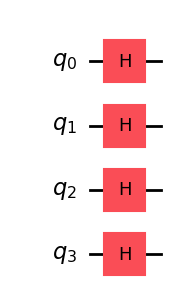

In [ ]:
# TODO: build a circuit on `grover_op.num_qubits` qubits and apply H to every qubit
# so that all basis states are equally likely.
qc_5_1 = QuantumCircuit(grover_op.num_qubits)
###################
# your code here
###################




###################


qc_5_1.draw(output="mpl", style="iqp")

In [ ]:
print(grade_5_1_superposition(qc_5_1))

### 5.2 — Apply one Grover layer

In [ ]:
# TODO: starting from qc_5_1, compose exactly one layer of the Grover operator
# compose a single grover operator onto a copy of the previously built qc_5_1 circuit.
qc_5_2 = qc_5_1.copy()
###################
# your code here
###################




###################
print("Angle to marked subspace:", angle_to_marked(qc_5_2, EXAMPLE_MARKED_STATES))

Angle to marked subspace: 0.4866949550747774


In [ ]:
print(grade_5_2_single_layer(qc_5_2))

### 5.3 — Measure and interpret

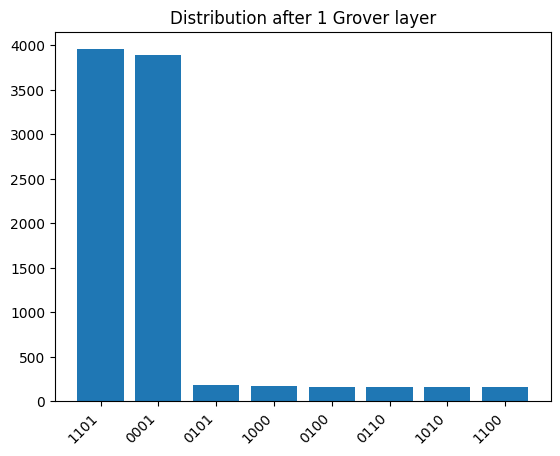

In [ ]:
# TODO: measure all qubits of qc_5_2 and run it through the sampler to get a
# distribution. Then plot a histogram of the top outcomes.
qc_5_3 = qc_5_2.copy()
###################
# your code here (measure_all)
###################




###################

# perform a simulated sampler on qc_5_3
sampler = StatevectorSampler()
result = sampler.run([qc_5_3], shots=10_000).result()
dist_5_3 = result[0].data.meas.get_counts()

# display the probability distribution histogram
top = sorted(dist_5_3.items(), key=lambda x: x[1], reverse=True)[:8]
keys, values = zip(*top)
plt.bar(keys, values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution after 1 Grover layer")
plt.show()

In [ ]:
# Based on the histogram above, which bitstring(s) do you think are marked?
my_guessed_states = ['1101', '0001']  # fill out this list
print(grade_5_3_readout(my_guessed_states, dist_5_3))

### 5.4 — Optimal number of iterations

In [ ]:
# TODO: compute the optimal number of iterations for this oracle,
# using the formula from Section 4.

M = None              # replace 'None' with your answer
N = None              # replace 'None' with your answer

my_optimal_n = None   # replace 'None' with your answer


In [ ]:
print(grade_5_4_iteration_count(my_optimal_n))

### 5.5 — Full run: optimal depth vs. over-rotation

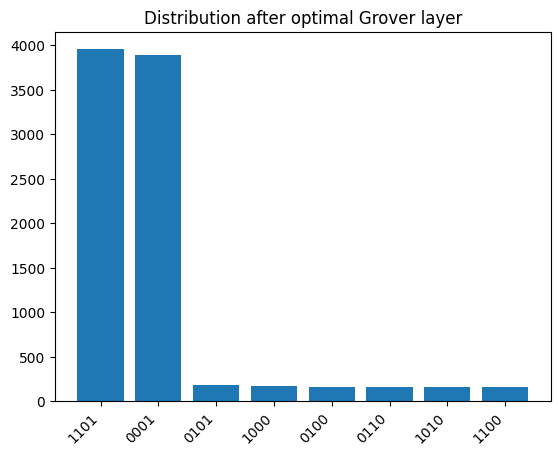

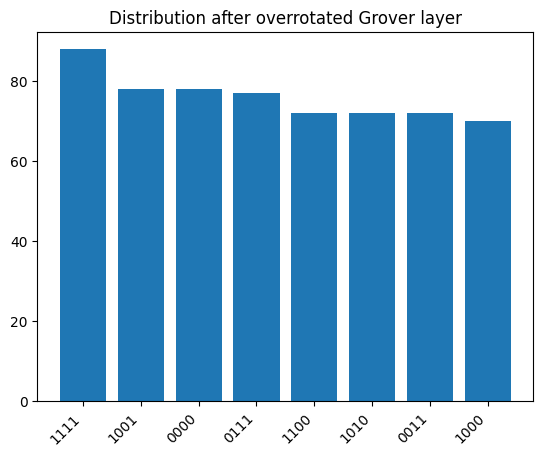

In [ ]:
# TODO: build and run two circuits: one using `my_optimal_n` layers, and one
# using `my_optimal_n + 2` layers. Store their measurement distributions as
# `dist_optimal` and `dist_overrotated`.

###################
# your code here (construct 'dist_optimal' and 'dist_overrotated')
###################


dist_optimal = None   # replace 'None' with your answer
dist_overrotated = None     # replace 'None' with your answer
###################

top_optimal = sorted(dist_optimal.items(), key=lambda x: x[1], reverse=True)[:8]
keys, values = zip(*top)
plt.bar(keys, values)
plt.xticks(rotation=45, ha="right")
plt.title(f"Distribution after optimal Grover layer")
plt.show()

top_overrotated = sorted(dist_overrotated.items(), key=lambda x: x[1], reverse=True)[:8]
keys, values = zip(*top_overrotated)
plt.bar(keys, values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution after overrotated Grover layer")
plt.show()

In [ ]:
print(grade_5_5_full_run(dist_optimal, dist_overrotated))

### Summary table

Putting it all together: for each Grover layer, the marked-state probability, and the angle to the marked subspace.

In [ ]:
sampler = StatevectorSampler(seed=42)
rows = []
for k in range(my_optimal_n + 3):
    qc = QuantumCircuit(grover_op.num_qubits)
    qc.h(range(grover_op.num_qubits))
    qc.compose(grover_op.power(k), inplace=True)
    angle = angle_to_marked(qc, EXAMPLE_MARKED_STATES)

    qc_meas = qc.copy()
    qc_meas.measure_all()
    result = sampler.run([qc_meas], shots=2000).result()
    dist = result[0].data.meas.get_counts()
    p_marked = sum(dist.get(s, 0) for s in EXAMPLE_MARKED_STATES) / 2000

    rows.append((k, round(p_marked, 3), round(angle, 3)))

print(f"{'Layer':>6} {'P(marked)':>10} {'Angle (rad)':>12}\n"+"-"*30)
for row in rows:
    print(f"{row[0]:>6} {row[1]:>10} {row[2]:>12}")

## 6 - Guess the secret oracles

Now you'll apply what Section 5 taught to two oracles whose marked states you don't get to see. It is your task to figure out the secret bitstrings using the Grover's algorithm.

### 6.1 — Secret oracle 1: reinforcing the quantum query

`get_secret_oracle_1()` returns an 8-qubit oracle and **one** marked state, revealed to you. The number of *other* marked states is not disclosed — that's the Section 6.3 bonus.

Use the same single-query mechanism from Section 3 (`quantum_query`) to test:
(a) the revealed marked state, and
(b) some other bitstring you choose that you don't expect to be marked.

In [ ]:
secret_oracle_1, revealed_state = get_secret_oracle_1()
print("Revealed marked state:", revealed_state)

In [ ]:
# TODO: query the revealed state, and query some other bitstring of your choosing.
result_correct = quantum_query(secret_oracle_1, None)    # replace 'None' with your code
result_incorrect = quantum_query(secret_oracle_1, None)  # replace 'None' with your code

print("Correct query result:", result_correct)
print("Incorrect query result:", result_incorrect)

In [ ]:
print(grade_6_1_query_intro(result_correct, result_incorrect))

### 6.2 — Secret oracle 2: main exercise

`get_secret_oracle_2()` returns a 5-qubit oracle and the **declared** number of marked states $M$ — the states themselves are hidden. Reuse the full Section 5 pipeline: superposition, compute the optimal iteration count from this $M$, apply that many layers, measure, and read off the marked bitstrings.

Grading here gives correct/incorrect only — no further detail — so you're not able to fish for the answer by trial and error.

In [ ]:
secret_oracle_2, declared_M = get_secret_oracle_2()
print("Declared number of marked states:", declared_M)

In [ ]:
# TODO: build the full Grover pipeline for secret_oracle_2, using declared_M
# to compute the optimal iteration count. Measure and inspect the histogram.

###################
# your code here
###################





###################

In [ ]:
# Based on your histogram, what are the marked states?
my_secret_2_guess = ["00111", "00001", "10001"]  # e.g. ["11111", "00001", "11101"]
print(grade_6_2_secret_oracle(my_secret_2_guess))

### 6.3 — Bonus: discover the rest of secret oracle 1
*(optional, time permitting)*

Revisit secret oracle 1. You now know one of its marked states but not $M$, nor the rest. Apply the full search pipeline from Sections 5/6.2 (without knowing $M$ in advance, you'll need to try a few iteration counts, or sweep over several) to find the remaining marked states.

In [ ]:
# TODO: search secret_oracle_1 for its remaining marked states.

# your code here

In [ ]:
my_secret_1_guess = []  # all marked states you believe you've found, including the revealed one
print(grade_6_3_bonus_discovery(my_secret_1_guess))

## 7 - *(Optional, self-paced)* Build your own oracle from scratch

This section is written to be worked through on your own, without an instructor walking through it live — whether that's during the workshop if you finish early, or afterwards. It stands alone: you don't need to remember every detail from earlier sections, though it does reuse code and variables from **Section 5**, so make sure those cells have been run first.

**A quick recap, since this section may be read separately from the rest:** an oracle marks certain basis states by flipping their phase. Section 3 showed you a working oracle being *used*. This section shows you how one gets *built*, starting from a single marked state and working up to the general case.

**Goal:** by the end of this section, you'll have built, from scratch, a function that constructs the exact same kind of oracle used throughout Sections 3 and 5 — for *any* list of marked states, not just the fixed example.

**A note before you start:** this section expects some comfort with basic programming — in particular, looping over a list, and finding positions of characters within a string (e.g. "which indices of this bitstring are `'0'`?"). If those are unfamiliar, that's alright — take it slowly, and treat working through them as part of what this section teaches.

### 7.3 — Step A: one marked state, by hand

Let's mark a single fixed state, `"1101"`, on 4 qubits — the same bitstring you've seen throughout Sections 3 and 5. Recall the construction: for each position where the marked state has a `'0'`, sandwich that qubit between X gates around a multi-controlled-Z. This flips the sign of exactly the `"1101"` basis state and leaves every other basis state alone.

Work out by hand which qubit positions need the X-sandwich for `"1101"` (remember: Qiskit's bit ordering is reversed relative to how the string reads left-to-right), and type those indices directly below.

In [ ]:
marked_state_a = "1101"
qc_7_3 = QuantumCircuit(4)

# TODO: apply X to the qubit(s) corresponding to the '0' position(s) of marked_state_a
# your code here

# TODO: apply a multi-controlled-Z across all 4 qubits
# your code here

# TODO: undo the X gate(s) you applied above
# your code here

qc_7_3.draw(output="mpl", style="iqp")

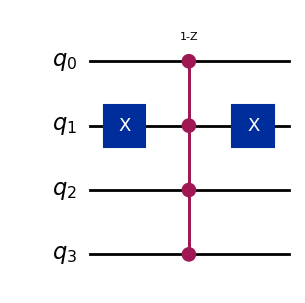

In [ ]:
#@title Solution — Step A (click ▶ to reveal) { display-mode: "form" }
marked_state_a_solution = "1101"
qc_7_3_solution = QuantumCircuit(4)

rev = marked_state_a_solution[::-1]
zero_inds = [i for i in range(4) if rev[i] == "0"]

qc_7_3_solution.x(zero_inds)
qc_7_3_solution.compose(MCMTGate(ZGate(), 3, 1), inplace=True)
qc_7_3_solution.x(zero_inds)

qc_7_3_solution.draw(output="mpl", style="iqp")

In [ ]:
print(grade_7_3_step_a(qc_7_3, marked_state=marked_state_a))

### 7.3b — Exercise: a different case

Repeat the same manual process for a **different** marked state on **5 qubits**: `"01101"`. You'll need to work out the zero positions yourself — the indices from Step A won't transfer directly.

In [ ]:
marked_state_a_ex = "01101"
qc_7_3b = QuantumCircuit(5)

# TODO: repeat the Step A process for marked_state_a_ex (5 qubits this time)
# your code here

qc_7_3b.draw(output="mpl", style="iqp")

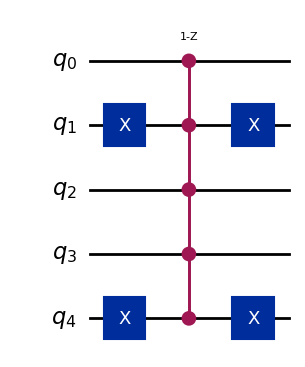

In [ ]:
#@title Solution — Step A exercise (click ▶ to reveal) { display-mode: "form" }
marked_state_a_ex_solution = "01101"
qc_7_3b_solution = QuantumCircuit(5)

rev = marked_state_a_ex_solution[::-1]
zero_inds = [i for i in range(5) if rev[i] == "0"]

qc_7_3b_solution.x(zero_inds)
qc_7_3b_solution.compose(MCMTGate(ZGate(), 4, 1), inplace=True)
qc_7_3b_solution.x(zero_inds)

qc_7_3b_solution.draw(output="mpl", style="iqp")

In [ ]:
print(grade_7_3_step_a_exercise(qc_7_3b, marked_state=marked_state_a_ex))

### 7.4 — Step B: generalise to any single marked state

Turn the manual process above into a function that works for *any* bitstring you pass it. This is where the string-processing note above matters: you'll need to find the zero positions **programmatically** (e.g. by looping over the string's characters) rather than reading them off by eye.

In [ ]:
def build_oracle_single(marked_state):
    num_qubits = len(marked_state)
    qc = QuantumCircuit(num_qubits)

    # TODO: find the zero positions of marked_state programmatically
    # (remember the bit-order reversal), then apply the same
    # X - multi-controlled-Z - X sandwich as in Step A.
    # your code here

    return qc.to_gate()

In [ ]:
#@title Solution — Step B (click ▶ to reveal) { display-mode: "form" }
def build_oracle_single_solution(marked_state):
    num_qubits = len(marked_state)
    qc = QuantumCircuit(num_qubits)

    rev_target = marked_state[::-1]
    zero_inds = [i for i in range(num_qubits) if rev_target[i] == "0"]

    if zero_inds:
        qc.x(zero_inds)
    if num_qubits == 1:
        qc.z(0)
    else:
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    if zero_inds:
        qc.x(zero_inds)

    return qc.to_gate()

In [ ]:
print(grade_7_4_step_b(build_oracle_single))

### 7.5 — Step C: multiple marked states

Finally, extend Step B to accept a **list** of marked states, looping over each one and applying the same construction for each. Once this works, it's the same function as `build_quantum_oracle` from the workshop package — you'll have built, from scratch, exactly what's been powering Sections 3 and 5 all along.

In [ ]:
def build_oracle_multi(marked_states):
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)

    # TODO: loop over marked_states, applying the Step B construction for each
    # your code here

    return qc.to_gate()

In [ ]:
#@title Solution — Step C (click ▶ to reveal) { display-mode: "form" }
def build_oracle_multi_solution(marked_states):
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)

    for target in marked_states:
        rev_target = target[::-1]
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == "0"]

        if zero_inds:
            qc.x(zero_inds)
        if num_qubits == 1:
            qc.z(0)
        else:
            qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)

    return qc.to_gate()

In [ ]:
print(grade_7_5_step_c(build_oracle_multi))

### 7.6 — Plug your oracle into Grover
*(optional)*

Take the oracle your own `build_oracle_multi` produces for `EXAMPLE_MARKED_STATES`, and run it through the exact Section 5 pipeline — `grover_operator`, superposition, layers, measurement — reusing the `my_optimal_n` you already computed there. You should see the same sharpening histogram you saw in Section 5, now produced by an oracle you built yourself.

In [ ]:
my_oracle = build_oracle_multi(EXAMPLE_MARKED_STATES)
my_grover_op = grover_operator(my_oracle)

qc_7_6 = QuantumCircuit(my_grover_op.num_qubits)
qc_7_6.h(range(my_grover_op.num_qubits))
qc_7_6.compose(my_grover_op.power(my_optimal_n), inplace=True)
qc_7_6.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc_7_6], shots=2000).result()
dist_7_6 = result[0].data.meas.get_counts()

top = sorted(dist_7_6.items(), key=lambda x: x[1], reverse=True)[:8]
keys, values = zip(*top)
plt.bar(keys, values)
plt.xticks(rotation=45, ha="right")
plt.title("Grover's algorithm running on your own oracle")
plt.show()